<a href="https://colab.research.google.com/github/pradeep-dani/pd-mt-iiitdh-colab/blob/main/main/ds-lab-assignments/assigments/DS_Lab_Assignment_7_L1_L2_regularisation_25MDA097_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# (Admission predict Dataset) Using the supplied predictive variables (GRE score, TOEFL score, University Rating, etc.)
# in the given dataset and predict the admission chance of a new candidate using Linear Regression.

import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "admission_data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mukeshmanral/graduates-admission-prediction",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())
print("Original rows:", len(df))

df = df.drop_duplicates()
print("After dropping duplicates:", len(df))

if 'Serial No.' in df.columns:
    df = df.drop(columns=['Serial No.'])
df.head()

/tmp/ipython-input-1876581816.py:18: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'graduates-admission-prediction' dataset.
First 5 records:    GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  Research  \
0        337          118                  4  4.5   4.5  9.65         1   
1        324          107                  4  4.0   4.5  8.87         1   
2        316          104                  3  3.0   3.5  8.00         1   
3        322          110                  3  3.5   2.5  8.67         1   
4        314          103                  2  2.0   3.0  8.21         0   

   Chance of Admit   
0              0.92  
1              0.76  
2              0.72  
3              0.80  
4              0.65  
Original rows: 500
After dropping duplicates: 500


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [6]:
# 1.1 Divide the data into the train-test split of 80:20.

possible_targets = [c for c in df.columns if 'Chance' in c or 'Admit' in c and c.lower().find('chance')!=-1]

if 'Chance of Admit ' in df.columns:
    target_col = 'Chance of Admit '
elif 'Chance of Admit' in df.columns:
    target_col = 'Chance of Admit'
elif 'Chance of Admit (2018)' in df.columns:
    target_col = 'Chance of Admit (2018)'
else:
    target_col = df.columns[-1]


print("Using target:", target_col)
X = df.drop(columns=[target_col]).values.astype(float)
y = df[target_col].values.astype(float).reshape(-1, 1)


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_b = np.hstack([np.ones((X_scaled.shape[0], 1)), X_scaled])

X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)
print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)

Using target: Chance of Admit 
Train shapes: (400, 8) (400, 1)
Test shapes: (100, 8) (100, 1)


In [7]:
# 1.2 Implement the Linear Regression Model to Predict the chances of admission.

theta_closed = np.linalg.pinv(X_train.T.dot(X_train)).dot(X_train.T).dot(y_train)

y_train_pred_closed = X_train.dot(theta_closed)
y_test_pred_closed = X_test.dot(theta_closed)

def sse(y_true, y_pred): return np.sum((y_true - y_pred)**2)

print("Closed-form Coefficients (including intercept):")
print(theta_closed.ravel())
print("Train SSE, MSE, R2:", sse(y_train, y_train_pred_closed), mean_squared_error(y_train, y_train_pred_closed), r2_score(y_train, y_train_pred_closed))
print("Test  SSE, MSE, R2:", sse(y_test, y_test_pred_closed), mean_squared_error(y_test, y_test_pred_closed), r2_score(y_test, y_test_pred_closed))

Closed-form Coefficients (including intercept):
[0.72283072 0.02746983 0.01820228 0.00293451 0.00179558 0.01593692
 0.06798973 0.01192658]
Train SSE, MSE, R2: 1.4106221913823034 0.0035265554784557583 0.8210671369321554
Test  SSE, MSE, R2: 0.3704655398788401 0.003704655398788401 0.8188432567829633


In [9]:
# 1.3 Implement the Gradient Descent with SSE to Optimize the model for up to 100 iterations and predict the test set.

learning_rate = 0.01
n_iters = 100

m, n = X_train.shape
theta = np.zeros((n, 1))

train_sse_history = []
for it in range(n_iters):
    preds = X_train.dot(theta)
    error = preds - y_train
    grad = (2/m) * (X_train.T.dot(error))
    theta = theta - learning_rate * grad
    train_sse_history.append(sse(y_train, X_train.dot(theta)))

y_train_pred_gd = X_train.dot(theta)
y_test_pred_gd = X_test.dot(theta)

print("y_train_pred_gd", y_train_pred_gd)
print("y_test_pred_gd", y_test_pred_gd)

y_train_pred_gd [[0.69375314]
 [0.66864702]
 [0.53446043]
 [0.57835644]
 [0.56383072]
 [0.49060484]
 [0.6153271 ]
 [0.70189875]
 [0.54208181]
 [0.59588973]
 [0.53462233]
 [0.86276792]
 [0.74477171]
 [0.88326011]
 [0.38748478]
 [0.7064196 ]
 [0.55890293]
 [0.79861608]
 [0.42164058]
 [0.5778675 ]
 [0.60799483]
 [0.80733444]
 [0.63153173]
 [0.64322486]
 [0.60661114]
 [0.59897799]
 [0.51366512]
 [0.8838002 ]
 [0.73146187]
 [0.40446782]
 [0.64289266]
 [0.63926732]
 [0.73372025]
 [0.40634575]
 [0.71666419]
 [0.42786576]
 [0.74499104]
 [0.857521  ]
 [0.59843955]
 [0.55990164]
 [0.70127136]
 [0.52720489]
 [0.72751088]
 [0.44237963]
 [0.83885224]
 [0.5448749 ]
 [0.87040838]
 [0.7102609 ]
 [0.56285907]
 [0.61397153]
 [0.78582254]
 [0.54213199]
 [0.73957954]
 [0.62296905]
 [0.52963456]
 [0.51849275]
 [0.65855393]
 [0.70185002]
 [0.43864589]
 [0.50507403]
 [0.58074841]
 [0.66043551]
 [0.59644991]
 [0.4214197 ]
 [0.53654246]
 [0.53905776]
 [0.68370615]
 [0.50969588]
 [0.63116747]
 [0.83259845]
 [0.

In [10]:
# 1.4 Print the Coefficients of the Optimized model.

print("Gradient Descent Coefficients (including intercept):")
print(theta.ravel())

Gradient Descent Coefficients (including intercept):
[0.62680224 0.03605431 0.03148792 0.00869098 0.01017968 0.01419727
 0.03843299 0.00932653]


In [11]:
# 1.5 Print the SSE, MSE, and R2 scores for the Train and Test Sets.

print("Train SSE, MSE, R2:", sse(y_train, y_train_pred_gd), mean_squared_error(y_train, y_train_pred_gd), r2_score(y_train, y_train_pred_gd))
print("Test  SSE, MSE, R2:", sse(y_test, y_test_pred_gd), mean_squared_error(y_test, y_test_pred_gd), r2_score(y_test, y_test_pred_gd))

Train SSE, MSE, R2: 5.167190341344247 0.012917975853360616 0.34455861573592517
Test  SSE, MSE, R2: 1.2520283094596767 0.012520283094596766 0.3877612178681289


In [12]:
# 2. Step-1: Define input array X with angles from 60 deg to 360 deg converted in radians.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(42)
angles_deg = np.arange(60, 361)
X_deg = angles_deg.reshape(-1, 1)
X_rad = np.deg2rad(X_deg).astype(float)

print("X_deg", X_deg)
print("X_rad", X_rad)

X_deg [[ 60]
 [ 61]
 [ 62]
 [ 63]
 [ 64]
 [ 65]
 [ 66]
 [ 67]
 [ 68]
 [ 69]
 [ 70]
 [ 71]
 [ 72]
 [ 73]
 [ 74]
 [ 75]
 [ 76]
 [ 77]
 [ 78]
 [ 79]
 [ 80]
 [ 81]
 [ 82]
 [ 83]
 [ 84]
 [ 85]
 [ 86]
 [ 87]
 [ 88]
 [ 89]
 [ 90]
 [ 91]
 [ 92]
 [ 93]
 [ 94]
 [ 95]
 [ 96]
 [ 97]
 [ 98]
 [ 99]
 [100]
 [101]
 [102]
 [103]
 [104]
 [105]
 [106]
 [107]
 [108]
 [109]
 [110]
 [111]
 [112]
 [113]
 [114]
 [115]
 [116]
 [117]
 [118]
 [119]
 [120]
 [121]
 [122]
 [123]
 [124]
 [125]
 [126]
 [127]
 [128]
 [129]
 [130]
 [131]
 [132]
 [133]
 [134]
 [135]
 [136]
 [137]
 [138]
 [139]
 [140]
 [141]
 [142]
 [143]
 [144]
 [145]
 [146]
 [147]
 [148]
 [149]
 [150]
 [151]
 [152]
 [153]
 [154]
 [155]
 [156]
 [157]
 [158]
 [159]
 [160]
 [161]
 [162]
 [163]
 [164]
 [165]
 [166]
 [167]
 [168]
 [169]
 [170]
 [171]
 [172]
 [173]
 [174]
 [175]
 [176]
 [177]
 [178]
 [179]
 [180]
 [181]
 [182]
 [183]
 [184]
 [185]
 [186]
 [187]
 [188]
 [189]
 [190]
 [191]
 [192]
 [193]
 [194]
 [195]
 [196]
 [197]
 [198]
 [199]
 [200]
 [201]


In [13]:
# 2. Step-2: Compute Y as Y=[Sin(X)+Cos(X)] + K^2 where K is a random number generated from normal distribution with 0.5 mean and 0.15 std dev.

K = rng.normal(loc=0.5, scale=0.15, size=(X_rad.shape[0], 1))
Y = (np.sin(X_rad) + np.cos(X_rad)).reshape(-1,1) + (K**2)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_rad, Y, test_size=0.2, random_state=1)
print("Synthetic data shapes:", X_train.shape, y_train.shape)

Synthetic data shapes: (240, 1) (240, 1)


In [15]:
# 2. Step-3: Create Linear Regression model with SSE as error, and different Non-Linear Regression models of 3, 13th and 15th degree polynomials on data created in step-1 and step-2.

degrees = [1, 3, 13, 15]
models = {}
results = {}


for deg in degrees:
    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=deg, include_bias=True)),
        ("linreg", LinearRegression())
    ])
    pipe.fit(X_train, y_train.ravel())
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)
    sse_train = np.sum((y_train.ravel() - y_train_pred.ravel())**2)
    sse_test  = np.sum((y_test.ravel()  - y_test_pred.ravel())**2)
    coef = pipe.named_steps['linreg'].coef_
    intercept = pipe.named_steps['linreg'].intercept_
    models[deg] = pipe
    results[deg] = {
        'sse_train': sse_train,
        'sse_test': sse_test,
        'mse_train': mean_squared_error(y_train, y_train_pred),
        'mse_test': mean_squared_error(y_test, y_test_pred),
        'r2_train': r2_score(y_train, y_train_pred),
        'r2_test': r2_score(y_test, y_test_pred),
        'intercept': intercept,
        'coefficients': coef
    }
    print(f"Degree {deg}: Train SSE={sse_train:.6f}, Test SSE={sse_test:.6f}")
    print("Intercept:", intercept)
    print("Number of coefficients:", coef.shape)
    print("=="*50)

Degree 1: Train SSE=177.230923, Test SSE=50.011189
Intercept: 0.6392643483017958
Number of coefficients: (2,)
Degree 3: Train SSE=9.304674, Test SSE=4.199499
Intercept: 3.734832203231639
Number of coefficients: (4,)
Degree 13: Train SSE=4.582029, Test SSE=1.858975
Intercept: 2.3300359393034196
Number of coefficients: (14,)
Degree 15: Train SSE=4.583747, Test SSE=1.856988
Intercept: 1.5711141320008064
Number of coefficients: (16,)


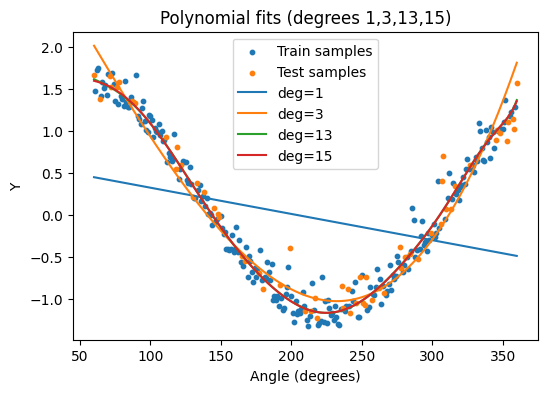

15th degree model metrics:
Train SSE: 4.583746589804909
Test  SSE: 1.85698793272535
Intercept: 1.5711141320008064
Coefficients (first 20 shown): [ 0.00000000e+00  4.26694549e-02  6.16944607e-02  3.93428955e-02
 -2.23495991e-02 -7.96077205e-02 -6.03421547e-02  3.96465814e-02
  6.22539898e-02 -7.00888304e-02  3.17869708e-02 -8.17084848e-03
  1.28350192e-03 -1.22322925e-04  6.50501983e-06 -1.48015970e-07]
First 10 predictions on test set (15th degree):
[ 0.99339287  0.06846263 -1.11359715 -0.61037353 -0.51585278 -0.80009575
 -0.93380674  0.27706334  1.05070382 -1.14894327]


In [20]:
# 2. Step-4: Plot the created models for the power of 1, 3,13, 15, and print the SSE, Coefficients for the plotted models, and print the prediction of test set on 15th Deg. Polynomial model.

plt.figure(figsize=(6,4))

X_plot = np.linspace(np.deg2rad(60), np.deg2rad(360), 500).reshape(-1,1)
plt.scatter(np.rad2deg(X_train), y_train, s=10, label='Train samples')
plt.scatter(np.rad2deg(X_test), y_test, s=10, label='Test samples')


for deg in degrees:
    y_plot = models[deg].predict(X_plot)
    plt.plot(np.rad2deg(X_plot), y_plot, label=f"deg={deg}")

plt.xlabel("Angle (degrees)")
plt.ylabel("Y")
plt.legend()
plt.title("Polynomial fits (degrees 1,3,13,15)")
plt.show()

print("15th degree model metrics:")
print("Train SSE:", results[deg]['sse_train'])
print("Test  SSE:", results[deg]['sse_test'])
print("Intercept:", results[deg]['intercept'])
print("Coefficients (first 20 shown):", results[deg]['coefficients'][:20])
y_test_pred_15 = models[15].predict(X_test)
print("First 10 predictions on test set (15th degree):")
print(y_test_pred_15[:10])

In [22]:
# 2. Step-5: Add the L2 regularization to the nonlinear regression model with 15th degree polynomial created in Step 3.
 # (Optimize for Max. of 50 Iterations and lambda values [1e-10 and 1e-5])

from sklearn.linear_model import SGDRegressor
lambdas = [1e-10, 1e-5]
ridge_models = {}

for lam in lambdas:

    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=15, include_bias=True)),
        ("sgd", SGDRegressor(penalty='l2', alpha=lam, max_iter=50, tol=1e-6, random_state=0))
    ])

    pipe.fit(X_train, y_train.ravel())
    y_train_pred = pipe.predict(X_train)
    y_test_pred  = pipe.predict(X_test)
    sse_train = np.sum((y_train.ravel() - y_train_pred.ravel())**2)
    sse_test  = np.sum((y_test.ravel()  - y_test_pred.ravel())**2)

    coef = pipe.named_steps['sgd'].coef_
    intercept = pipe.named_steps['sgd'].intercept_
    ridge_models[lam] = pipe
    print(f"lambda={lam}: Train SSE={sse_train:.6f}, Test SSE={sse_test:.6f}")
    print("Intercept:", intercept)
    print("Number of coefficients:", coef.shape)
    print("=="*40)

lambda=1e-10: Train SSE=33787968261988488011842251692786938413878748035275210262986096640.000000, Test SSE=22871301032949478182160113797410953068285864621742248746823974912.000000
Intercept: [2.65302068e+11]
Number of coefficients: (16,)
lambda=1e-05: Train SSE=33786566154248266003384600519864031616860075065421240520052572160.000000, Test SSE=22870345880594835659544832380517768467368194516162221444077453312.000000
Intercept: [2.65302068e+11]
Number of coefficients: (16,)


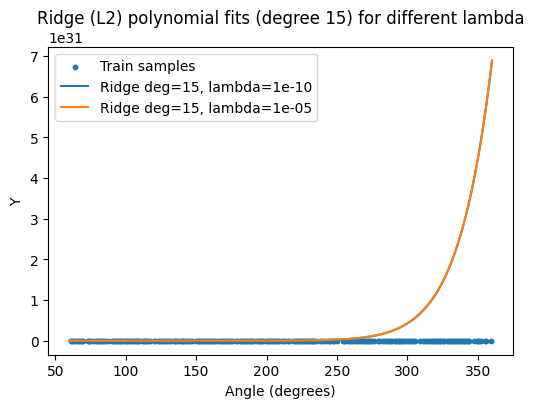

In [24]:
# 2. Step-6: Plot the Ridge (L2) regression models for lambda values [1e-10 and 1e-5] and print the SSE, Coefficients for the plotted models, and print the prediction of test set on 15th Deg. Polynomial model.

plt.figure(figsize=(6,4))
plt.scatter(np.rad2deg(X_train), y_train, s=10, label='Train samples')
X_plot = np.linspace(np.deg2rad(60), np.deg2rad(360), 500).reshape(-1,1)
for lam in lambdas:
    y_plot = ridge_models[lam].predict(X_plot)
    plt.plot(np.rad2deg(X_plot), y_plot, label=f"Ridge deg=15, lambda={lam}")
plt.xlabel("Angle (degrees)")
plt.ylabel("Y")
plt.legend()
plt.title("Ridge (L2) polynomial fits (degree 15) for different lambda")
plt.show()